<a href="https://colab.research.google.com/github/enriquejujuy/IPDI/blob/main/IPDI_TP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PROCESAMIENTO MORFOLOGICO**
## **CHOQUE Enrique Aniceto**

In [1]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
!pip install opencv-python # install opencv-python package
import cv2 # import the cv2 module

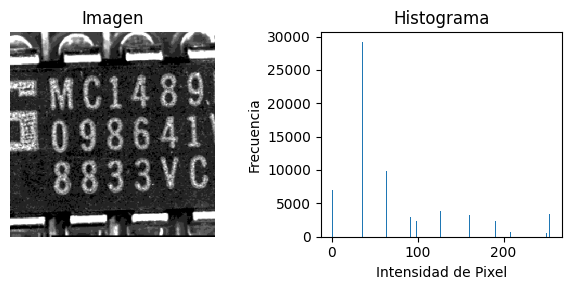

In [2]:
img = imageio.imread('/content/chip.bmp')
# Convertir a escala de grises (si no lo está ya)
if len(img.shape) == 3:
    img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

# Normalizar la imagen
img_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# Crear una figura con dos subplots de tamaño más pequeño
fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # Ajustar el tamaño de la figura

# Mostrar la imagen en el primer subplot
axes[0].imshow(img, 'gray')
axes[0].axis('off')  # Apagar los ejes
axes[0].set_title('Imagen')

# Mostrar el histograma en el segundo subplot
axes[1].hist(img.flatten(), bins=256, range=[0,255])
axes[1].set_xlabel('Intensidad de Pixel')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma')

# Ajustar el espaciado entre los subplots
plt.tight_layout()
plt.show()

## **BINARIZACION**

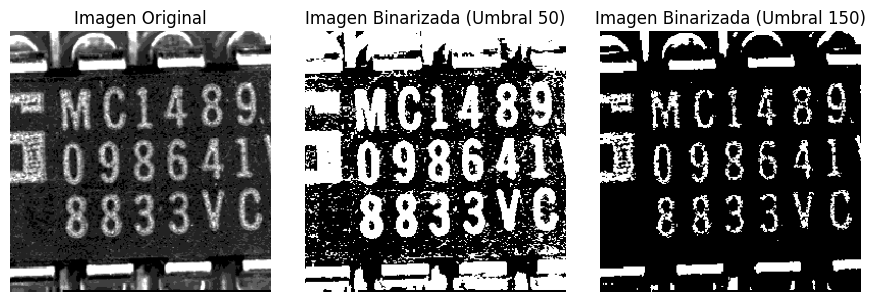

In [3]:
# Binarización con umbral bajo=50 y alto=150
umbral1 = 50
umbral2 = 150
_, img_binarizada1 = cv2.threshold(img_normalized, umbral1, 255, cv2.THRESH_BINARY)
_, img_binarizada2 = cv2.threshold(img_normalized, umbral2, 255, cv2.THRESH_BINARY)

# Mostrar la imagen original, binarizada con umbral bajo y la imagen binarizada con umbral alto
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(img, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Original')

axes[1].imshow(img_binarizada1, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Binarizada (Umbral {})'.format(umbral1))


axes[2].imshow(img_binarizada2, 'gray')
axes[2].axis('off')
axes[2].set_title('Imagen Binarizada (Umbral {})'.format(umbral2))

plt.tight_layout()
plt.show()

## **EROSION**

In [5]:
# Funcion para erosion de una imagen Con un elelmento estructurante kernel
def erosion(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded_image = cv2.erode(image, kernel, iterations=1)
    return eroded_image

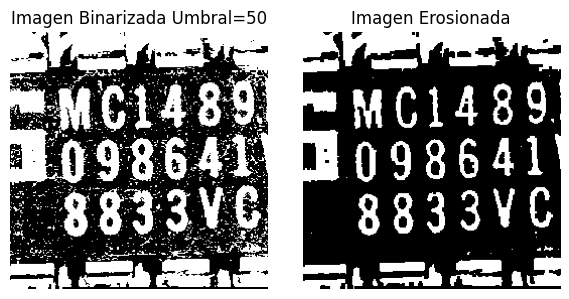

In [6]:
# Realizar la erosión
kernel_size = 3  # Define el tamaño del kernel
img_erosionada = erosion(img_binarizada1, kernel_size)

# Mostrar la imagen binarizada y la imagen erosionada
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=50')

axes[1].imshow(img_erosionada, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Erosionada')

plt.tight_layout()
plt.show()

## **DILATACION**

In [7]:
# Funcion para DILATACION de una imagen Con un elelmento estructurante kernel
def dilatar(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilate_image = cv2.dilate(image, kernel, iterations=1)
    return dilate_image

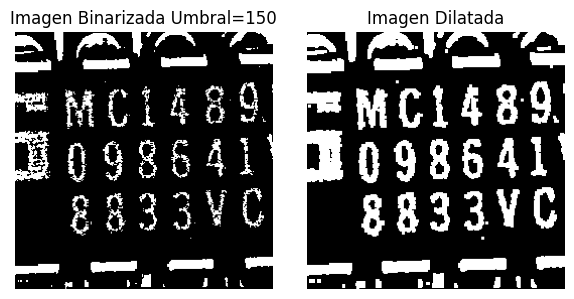

In [8]:
# Realizar la dilatacion
kernel_size = 3  # Define el tamaño del kernel
img_dilatada = dilatar(img_binarizada2, kernel_size)

# Mostrar la imagen binarizada y la imagen dilatada
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada2, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=150')

axes[1].imshow(img_dilatada, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Dilatada')

plt.tight_layout()
plt.show()

## **APERTURA**

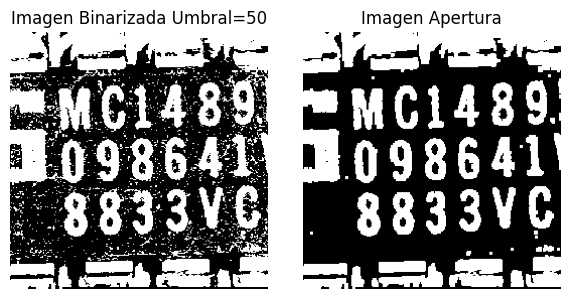

In [9]:
# Apertura Morfológica
kernel_size = 3
img_erosionada = erosion(img_binarizada1, kernel_size)
img_apertura = dilatar(img_erosionada, kernel_size)

# Mostrar la imagen binarizada y la imagen con apertura
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=50')

axes[1].imshow(img_apertura, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Apertura')

plt.tight_layout()
plt.show()

## **CIERRE**

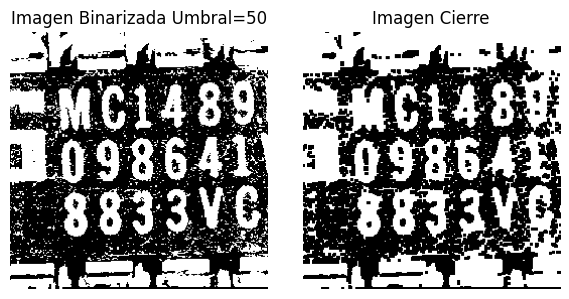

In [10]:
# Cierre Morfológico
kernel_size = 3
img_dilatada = dilatar(img_binarizada1, kernel_size)
img_cierre = erosion(img_dilatada, kernel_size)

# Mostrar la imagen binarizada y la imagen con cierre
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=50')

axes[1].imshow(img_cierre, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Cierre')

plt.tight_layout()
plt.show()

## **BORDE**

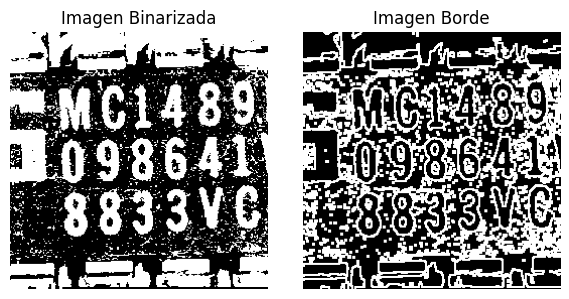

In [11]:
# prompt: crear borde morfologico de una imagen

# ## **BORDE**
# Borde Morfológico
kernel = np.ones((3, 3), np.uint8)  # Define el kernel para la operación de borde
img_borde = cv2.morphologyEx(img_binarizada1, cv2.MORPH_GRADIENT, kernel)

# Mostrar la imagen binarizada y la imagen con borde
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada')

axes[1].imshow(img_borde, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Borde')

plt.tight_layout()
plt.show()

# **BORDE INTERIOR**

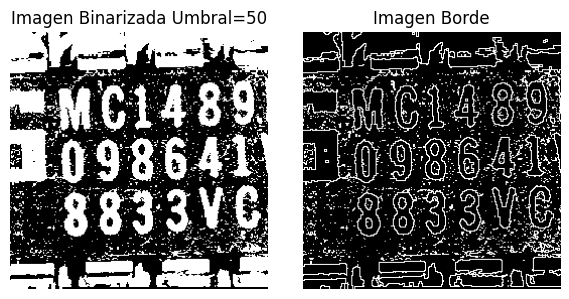

In [12]:
# BORDE INTERIOR Morfológico
kernel_size = 3
img_erosionada = erosion(img_binarizada1, kernel_size)
img_borde = img_binarizada1 - img_erosionada

# Mostrar la imagen binarizada y la imagen con cierre
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=50')

axes[1].imshow(img_borde, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Borde')

plt.tight_layout()
plt.show()

## **BORDE EXTERIOR**

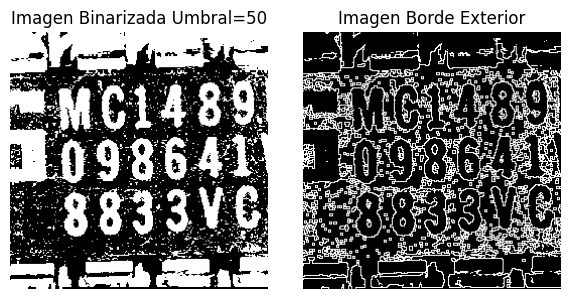

In [13]:
# prompt: CREAR borde exterior de una imagen

# BORDE EXTERIOR Morfológico
kernel_size = 3
img_dilatada = dilatar(img_binarizada1, kernel_size)
img_borde_exterior = img_dilatada - img_binarizada1

# Mostrar la imagen binarizada y la imagen con borde exterior
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_binarizada1, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Binarizada Umbral=50')

axes[1].imshow(img_borde_exterior, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen Borde Exterior')

plt.tight_layout()
plt.show()

## **MEDIANA**

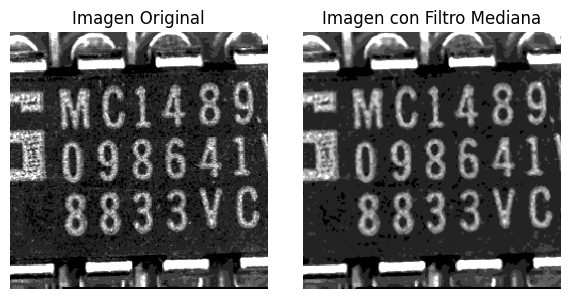

In [14]:
# Aplicar el filtro de mediana
img_mediana = cv2.medianBlur(img, 3)  # 3 es el tamaño del kernel (debe ser un número impar)

# Mostrar la imagen original y la imagen con el filtro de mediana
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img, 'gray')
axes[0].axis('off')
axes[0].set_title('Imagen Original')

axes[1].imshow(img_mediana, 'gray')
axes[1].axis('off')
axes[1].set_title('Imagen con Filtro Mediana')

plt.tight_layout()
plt.show()

## **FIN**